# 乗降モデルの基礎：格子上の一斉更新

対応章：[乗降モデルの基礎](../chapters/31_agent_boarding_basic.md)．

まず降車のみの一方向流で検証し，その後に乗車客を加える．降車客と乗車客がいる場合は同時に移動を試みる．モデルの完了時刻は計算領域の反対側の端へ全員が到達する時刻であり，実際の停車時間ではない．壁・固定障害物を避ける最短距離場と一斉更新を使う．

## ライブラリ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from copy import deepcopy

## 基準設定

ドア幅は `2*DOOR_HALF+1` セルである．初めは乗車0人とし，一方向流が完了することを検証する．人数を増やす前に，格子形状，初期配置，終了判定を読む．時間単位はステップ，長さ単位はセルである．

In [2]:
H, W, DOOR_COL, DOOR_HALF = 11, 21, 10, 2
N_ALIGHT, N_BOARD = 8, 0
MAX_STEPS = 300

## 距離場・候補・競合解決・一斉反映

`distance_field` は全ゴールから幅優先探索して，壁・固定障害物を避ける最小歩数を求める．人の占有は距離場に含めず，候補選択時に除く．全員が更新前に空いていたセルだけを候補にするので，そのステップで前の人が空けるセルへの追従や位置交換は許さない．

`propose_moves`，`resolve_proposals`，一斉反映を分ける．同じセルへの競合は必ず1人を無作為に通す．この規則では候補が全員にない状態は永久停止である．自発的な横移動や確率的な休止を追加した場合は，このデッドロック判定をそのまま使えない．

初期配置と更新の乱数列は分離する．配置を完全にそろえる比較には，seedだけでなく `initial_agents` の同じ内容を渡す．固定障害物は明示したセルであり，人数を持つ滞留者や譲歩行動の代用ではない．

In [3]:
def make_grid(H=11, W=21, door_col=10, door_half=2, obstacles=()):
    values = [H, W, door_col, door_half]
    if any(not isinstance(v, (int, np.integer)) for v in values):
        raise ValueError('grid dimensions and door indices must be integers')
    if H < 3 or W < 3 or not 0 < door_col < W-1 or not 0 <= door_half <= min(H//2, H-1-H//2):
        raise ValueError('invalid grid or door width')
    passable = np.ones((H, W), dtype=bool)
    passable[:, door_col] = False
    passable[H//2-door_half:H//2+door_half+1, door_col] = True
    for pos in obstacles:
        if len(pos) != 2 or any(not isinstance(v, (int, np.integer)) for v in pos):
            raise ValueError('obstacle positions must be integer (row, column) pairs')
        r, c = pos
        if not (0 <= r < H and 0 <= c < W) or not passable[r, c]:
            raise ValueError('obstacle must occupy a valid floor cell')
        passable[r, c] = False
    return passable


def neighbors(pos, shape):
    r, c = pos
    return [(nr, nc) for nr, nc in [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]
            if 0 <= nr < shape[0] and 0 <= nc < shape[1]]


def distance_field(passable, goal_col):
    # 全ゴールから幅優先探索する．人を除き，壁・固定障害物は考慮する．
    distance = np.full(passable.shape, np.inf)
    queue = deque()
    for row in range(passable.shape[0]):
        if passable[row, goal_col]:
            distance[row, goal_col] = 0
            queue.append((row, goal_col))
    while queue:
        pos = queue.popleft()
        for target in neighbors(pos, passable.shape):
            if passable[target] and np.isinf(distance[target]):
                distance[target] = distance[pos] + 1
                queue.append(target)
    return distance


def place_agents(passable, door_col, n_alight, n_board, seed=0, excluded=()):
    if any(not isinstance(n, (int, np.integer)) or n < 0 for n in [n_alight, n_board]):
        raise ValueError('passenger counts must be nonnegative integers')
    rng = np.random.default_rng(seed)
    excluded = set(map(tuple, excluded))
    agents = []
    for kind, count, columns in [('alight', n_alight, range(door_col)),
                                  ('board', n_board, range(door_col+1, passable.shape[1]))]:
        cells = [(r, c) for r in range(passable.shape[0]) for c in columns
                 if passable[r, c] and (r, c) not in excluded]
        if count > len(cells):
            raise ValueError('requested passenger count exceeds available cells')
        order = rng.permutation(len(cells))
        for index in order[:count]:
            agents.append(dict(id=len(agents), type=kind, pos=cells[index]))
    return agents


def occupied_cells(agents):
    return {a['pos'] for a in agents if not a['done']}


def check_state(agents, passable):
    active = [a for a in agents if not a['done']]
    assert len({a['id'] for a in agents}) == len(agents)
    assert len(occupied_cells(agents)) == len(active), 'overlapping passengers'
    assert all(passable[a['pos']] for a in active), 'passenger in wall/obstacle'


def propose_moves(agents, passable, fields, rng):
    # 全員が同じ更新前の占有状態を見る．占有セルへの追従・交換はしない．
    occupied = occupied_cells(agents)
    proposals = {}
    for a in agents:
        if a['done']:
            continue
        distance = fields[a['type']]
        options = [pos for pos in neighbors(a['pos'], passable.shape)
                   if passable[pos] and pos not in occupied and distance[pos] < distance[a['pos']]]
        if options:
            best = min(distance[pos] for pos in options)
            options = [pos for pos in options if distance[pos] == best]
            proposals[a['id']] = options[int(rng.integers(len(options)))]
    return proposals


def resolve_proposals(proposals, rng):
    by_target = {}
    for agent_id, target in proposals.items():
        by_target.setdefault(target, []).append(agent_id)
    winners = {}
    conflict_cells = 0
    for target, ids in sorted(by_target.items()):
        conflict_cells += int(len(ids) > 1)
        winner = ids[int(rng.integers(len(ids)))]
        winners[winner] = target
    return winners, conflict_cells


def simulate(H=11, W=21, door_col=10, door_half=2, n_alight=8, n_board=0,
             obstacles=(), max_steps=300, seed=0, initial_agents=None):
    if not isinstance(max_steps, (int, np.integer)) or max_steps < 1:
        raise ValueError('max_steps must be a positive integer')
    if any(not isinstance(n, (int, np.integer)) or n < 0 for n in [n_alight, n_board]):
        raise ValueError('passenger counts must be nonnegative integers')
    passable = make_grid(H, W, door_col, door_half, obstacles)
    # 32章の子SeedSequenceも受け取り，入力のspawn状態は変更しない．
    sequence = (np.random.SeedSequence(seed.entropy, spawn_key=seed.spawn_key, pool_size=seed.pool_size)
                if isinstance(seed, np.random.SeedSequence) else np.random.SeedSequence(seed))
    init_seed, update_seed = sequence.spawn(2)
    rng = np.random.default_rng(update_seed)
    initial = (place_agents(passable, door_col, n_alight, n_board, seed=init_seed)
               if initial_agents is None else deepcopy(initial_agents))
    if len(initial) != n_alight+n_board or len({a['id'] for a in initial}) != len(initial):
        raise ValueError('initial counts or IDs are inconsistent')
    if any(a['type'] not in ('alight', 'board') for a in initial):
        raise ValueError('unknown passenger type')
    if sum(a['type'] == 'alight' for a in initial) != n_alight:
        raise ValueError('initial passenger types do not match counts')
    fields = {'alight': distance_field(passable, W-1), 'board': distance_field(passable, 0)}
    agents = []
    for source in initial:
        pos = tuple(source['pos'])
        if len(pos) != 2 or any(not isinstance(v, (int, np.integer)) for v in pos):
            raise ValueError('passenger positions must be integer pairs')
        if not (0 <= pos[0] < H and 0 <= pos[1] < W) or not passable[pos]:
            raise ValueError('invalid initial position')
        d = fields[source['type']][pos]
        if not np.isfinite(d):
            raise ValueError('initial position cannot reach its goal through the static geometry')
        agents.append(dict(id=source['id'], type=source['type'], pos=pos, done=(d == 0),
                           finished_at=0 if d == 0 else None, moves=0, wait_steps=0))
    if len(occupied_cells(agents)) != sum(not a['done'] for a in agents):
        raise ValueError('overlapping initial passengers')
    # 完了済みも含め，初期配置の重複は許さない．
    if len({tuple(a['pos']) for a in initial}) != len(initial):
        raise ValueError('overlapping initial passengers')
    counts = np.zeros((H, W), dtype=int)
    history = []
    t = 0
    total_conflicts = 0
    status = 'cutoff'

    def record(moved=0, conflicts=0):
        history.append(dict(t=t, remaining_alight=sum(not a['done'] and a['type'] == 'alight' for a in agents),
                            remaining_board=sum(not a['done'] and a['type'] == 'board' for a in agents),
                            moved=moved, conflict_cells=conflicts))

    record()
    while t < max_steps:
        check_state(agents, passable)
        if all(a['done'] for a in agents):
            status = 'completed'
            break
        proposals = propose_moves(agents, passable, fields, rng)
        if not proposals:
            # この基準規則には自発移動・確率的休止がないため吸収状態と証明できる．
            status = 'deadlock'
            for a in agents:
                if not a['done']:
                    counts[a['pos']] += max_steps-t
                    a['wait_steps'] += max_steps-t
            break
        winners, conflicts = resolve_proposals(proposals, rng)
        for a in agents:
            if not a['done']:
                counts[a['pos']] += 1  # 時刻 t の占有を記録してから更新する．
                if a['id'] in winners:
                    a['pos'] = winners[a['id']]
                    a['moves'] += 1
                    if fields[a['type']][a['pos']] == 0:
                        a['done'], a['finished_at'] = True, t+1
                else:
                    a['wait_steps'] += 1
        t += 1
        total_conflicts += conflicts
        check_state(agents, passable)
        record(len(winners), conflicts)
    # 上限と同じ時刻に完了した試行も正常完了である．
    if all(a['done'] for a in agents):
        status = 'completed'
    completion = float(t) if status == 'completed' else np.nan

    def group_finish(kind):
        group = [a for a in agents if a['type'] == kind]
        return (float(max((a['finished_at'] for a in group), default=0))
                if all(a['done'] for a in group) else np.nan)

    return dict(status=status, completed=status == 'completed', cutoff=status == 'cutoff',
                completion_time=completion, capped_time=completion if status == 'completed' else float(max_steps),
                steps_evaluated=t, horizon=max_steps, remaining=sum(not a['done'] for a in agents),
                alight_finished=group_finish('alight'), board_finished=group_finish('board'),
                agents=agents, initial_agents=deepcopy(initial), history=pd.DataFrame(history),
                occupancy_counts=counts, occupancy_fraction=counts/max_steps, passable=passable,
                fields=fields, conflict_cells=total_conflicts)

## 小配置による検証

1人が同じ行を3セル進む例は3ステップで完了する．上限3でも `completed` であり，上限2なら `cutoff` である．中央の空セルを2人が狙う例では，勝者は必ず1人である．

In [4]:
one = [dict(id=0, type='alight', pos=(2, 1))]
small = dict(H=5, W=5, door_col=2, door_half=0, n_alight=1, n_board=0, initial_agents=one)
assert simulate(**small, max_steps=3)['completion_time'] == 3
assert simulate(**small, max_steps=2)['status'] == 'cutoff'
winners, conflicts = resolve_proposals({0: (2, 2), 1: (2, 2)}, np.random.default_rng(0))
assert len(winners) == 1 and conflicts == 1
print('single-agent travel, cutoff boundary, and exclusion checks passed')

single-agent travel, cutoff boundary, and exclusion checks passed


## 空間配置と最短距離場

左は初期配置，右は降車側のゴールまでの最小歩数である．障害物を越えて距離を測らず，ドアまで回り込む距離を含める．ゴールは右端の通行可能セル全体であり，ドアの中央1点ではない．

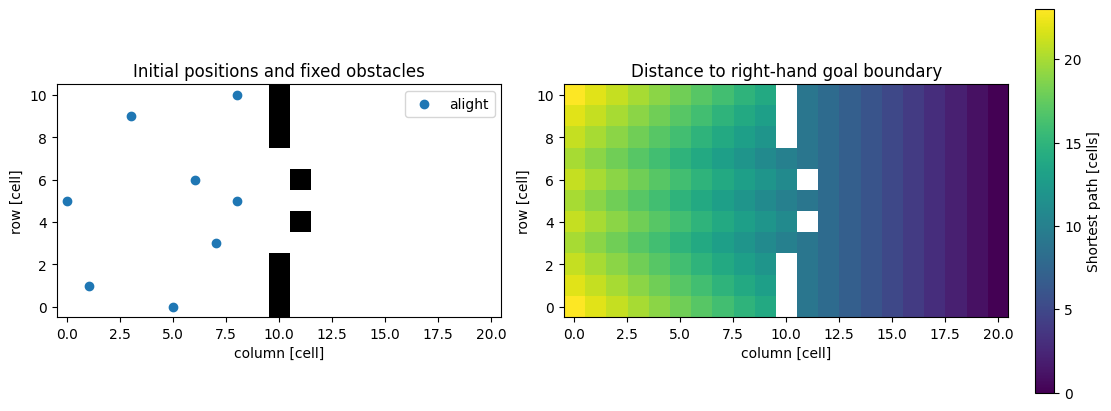

In [5]:
obstacles = [(4, 11), (6, 11)]
plain = make_grid(H, W, DOOR_COL, DOOR_HALF)
initial = place_agents(plain, DOOR_COL, N_ALIGHT, N_BOARD, seed=10, excluded=obstacles)
with_obstacles = make_grid(H, W, DOOR_COL, DOOR_HALF, obstacles)
distance = distance_field(with_obstacles, W-1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].imshow(with_obstacles, cmap='gray', vmin=0, vmax=1, origin='lower')
for kind, color in [('alight', 'tab:blue'), ('board', 'tab:red')]:
    positions = [a['pos'] for a in initial if a['type'] == kind]
    if positions:
        axes[0].scatter([p[1] for p in positions], [p[0] for p in positions], c=color, label=kind)
axes[0].legend()
im = axes[1].imshow(np.ma.masked_invalid(distance), origin='lower', cmap='viridis')
fig.colorbar(im, ax=axes[1], label='Shortest path [cells]')
axes[0].set_title('Initial positions and fixed obstacles')
axes[1].set_title('Distance to right-hand goal boundary')
for ax in axes:
    ax.set(xlabel='column [cell]', ylabel='row [cell]')
plt.show()

## 同じ初期配置で固定障害物の有無を比較する

今回は一方向流の基準確認であり，特定の人間行動の優劣を評価しているのではない．障害物を避ける距離場も条件ごとに計算し直す．

In [6]:
settings = dict(H=H, W=W, door_col=DOOR_COL, door_half=DOOR_HALF,
                n_alight=N_ALIGHT, n_board=N_BOARD, max_steps=MAX_STEPS, initial_agents=initial, seed=0)
results = [simulate(**settings), simulate(**settings, obstacles=obstacles)]
display(pd.DataFrame([{key: r[key] for key in ['status', 'completion_time', 'capped_time',
                                               'steps_evaluated', 'remaining', 'conflict_cells']}
                      for r in results], index=['no obstacle', 'fixed obstacles']))

,status,completion_time,capped_time,steps_evaluated,remaining,conflict_cells
no obstacle,completed,21.0,21.0,21,0,0
fixed obstacles,completed,21.0,21.0,21,0,0


## 共通の観測時間で占有率を比較する

時刻0から `C-1` の占有を足し，両条件とも `C=MAX_STEPS` で割る．完了後は0，証明された永久停止では最後の配置が続くとして補う．色は動く乗降客の時間平均占有率であり，固定障害物は灰色で除外する．実面積当たりの人数密度とは区別する．

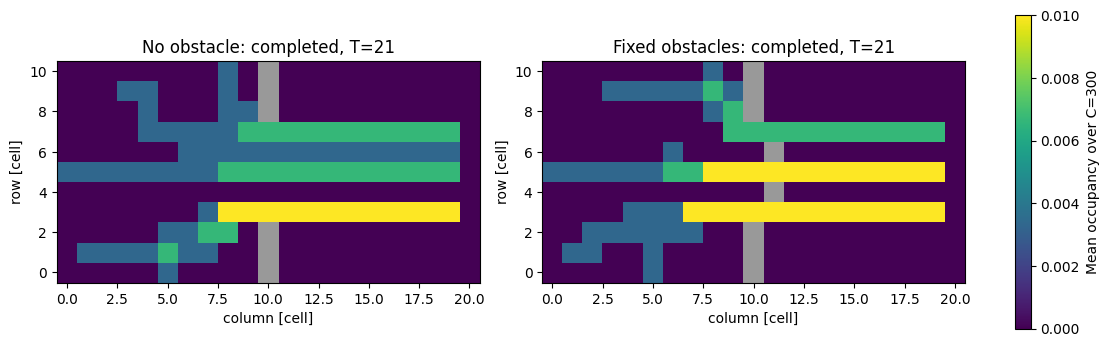

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
vmax = max(r['occupancy_fraction'].max() for r in results)
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('0.6')
for ax, name, result in zip(axes, ['No obstacle', 'Fixed obstacles'], results):
    field = np.ma.array(result['occupancy_fraction'], mask=~result['passable'])
    im = ax.imshow(field, origin='lower', cmap=cmap, vmin=0, vmax=max(vmax, 0.01))
    ax.set(title=f"{name}: {result['status']}, T={result['completion_time']:g}",
           xlabel='column [cell]', ylabel='row [cell]')
fig.colorbar(im, ax=axes.tolist(), label=f'Mean occupancy over C={MAX_STEPS}', shrink=0.8)
plt.show()

## 乗車人数だけを増やす

降車人数は8人に固定する．各点は複数の初期配置で反復し，完了率と上限制限時間を分けて表示する．後者は `Y=min(T,C)` の平均であり，未完了を含む真の平均完了時間ではない．この厳しい最短経路規則では対向者が避けられず，永久停止が生じうる．

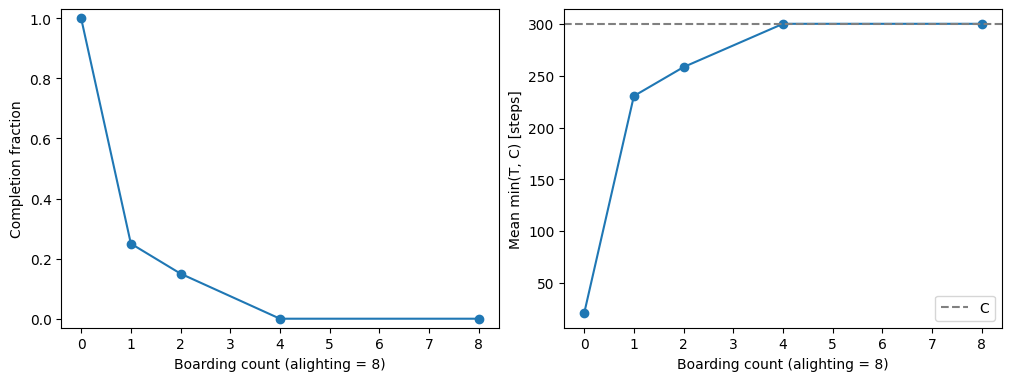

,completion_rate,mean_capped,completed_count
n_board,,,
0,1.00,21.05,20
1,0.25,230.40,5
2,0.15,258.30,3
4,0.00,300.00,0
8,0.00,300.00,0


status,completed,deadlock
n_board,,
0,20,0
1,5,15
2,3,17
4,0,20
8,0,20


In [8]:
rows = []
for n_board in [0, 1, 2, 4, 8]:
    for seed in range(20):
        result = simulate(n_alight=8, n_board=n_board, seed=seed, max_steps=MAX_STEPS)
        rows.append(dict(n_board=n_board, seed=seed, **{k: result[k] for k in
                         ['completion_time', 'capped_time', 'completed', 'status', 'remaining']}))
count_raw = pd.DataFrame(rows)
count_summary = count_raw.groupby('n_board').agg(completion_rate=('completed', 'mean'),
                      mean_capped=('capped_time', 'mean'), completed_count=('completed', 'sum'))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
axes[0].plot(count_summary.index, count_summary['completion_rate'], 'o-')
axes[0].set(xlabel='Boarding count (alighting = 8)', ylabel='Completion fraction', ylim=(-0.03, 1.03))
axes[1].plot(count_summary.index, count_summary['mean_capped'], 'o-')
axes[1].axhline(MAX_STEPS, color='gray', linestyle='--', label='C')
axes[1].set(xlabel='Boarding count (alighting = 8)', ylabel='Mean min(T, C) [steps]')
axes[1].legend()
plt.show()
display(count_summary)
display(pd.crosstab(count_raw['n_board'], count_raw['status']))

## 課題：実装と検証

1. `door_width_sweep(door_halves, seeds)` を作り，降車8人・乗車0人を基準に幅ごとの全試行を保存する．終了状態，完了時刻，上限制限時間 `capped_time`，残人数を記録し，完了率と時間の要約を表にする．
2. `passenger_count_sweep(counts, seeds)` を作り，降車8人を固定して乗車人数だけを変える．未完了の時刻を完了時間として平均せず，共通上限 `C` での `mean(min(T,C))` と完了率を示す．人数差が不均等でも比較できるように，平均の差を人数差で割った列を加える．
3. 初期配置の保存・複製を実装し，固定障害物の有無で同じ配置を使う．障害物を置く候補セルは両条件の初期配置から除外し，人数を変えない．
4. 1人の最短経路，2人の競合，向かい合う2人の停止を小配置で検証する．上限と同じ時刻の完了を誤って打切りとしないことも `assert` で確認する．
5. 1回の結果や少数条件から単調性を断定せず，完了率，未完了の状態，時間の変化を分けて説明する．

In [9]:
# 課題の関数をここに実装する．生データと終了状態を残す．